In [1]:
# LOGISTIC REGRESSION

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
titanic = fetch_openml('titanic', version=1, as_frame=True)
df = titanic['data']



In [3]:
df['survived'] = titanic['target']


In [4]:
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


<Axes: xlabel='survived', ylabel='count'>

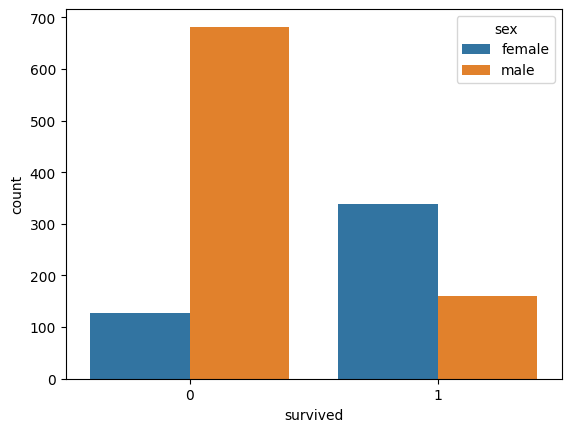

In [5]:
sns.countplot(x='survived', data =df,hue= 'sex')

<Axes: xlabel='survived', ylabel='count'>

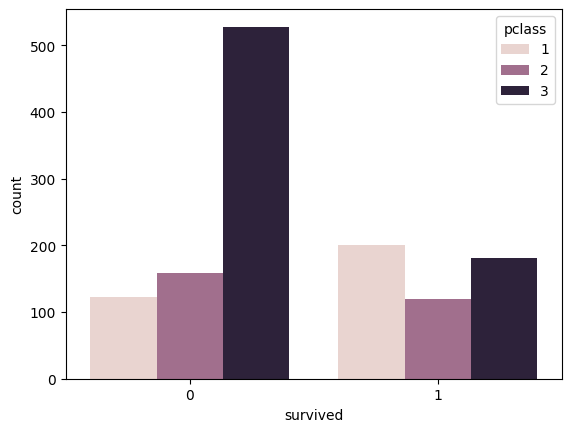

In [6]:
sns.countplot(x='survived', data =df,hue= 'pclass')

<Axes: ylabel='Frequency'>

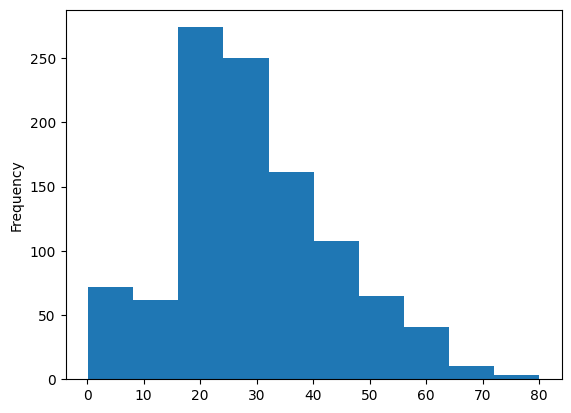

In [7]:
df['age'].plot(kind='hist') 

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   str     
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   str     
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    str     
 9   embarked   1307 non-null   category
 10  boat       486 non-null    str     
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    str     
 13  survived   1309 non-null   category
dtypes: category(3), float64(3), int64(3), str(5)
memory usage: 116.6 KB


In [9]:
df.isnull().sum()

pclass          0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
survived        0
dtype: int64

<Axes: title={'center': 'Missing values in percentage'}, ylabel='percentage'>

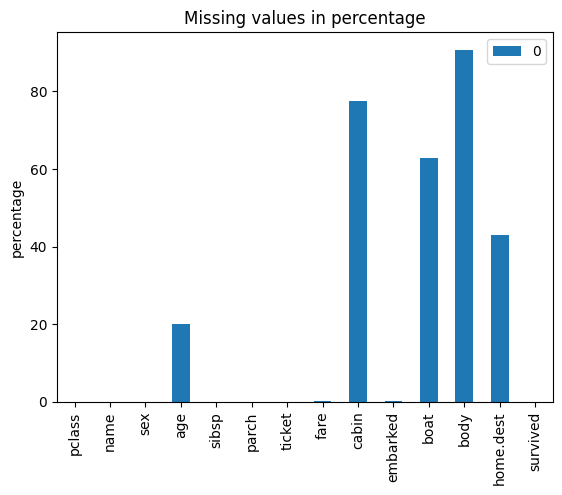

In [10]:
null_percent = pd.DataFrame(df.isnull().sum()/len(df) *100)
null_percent.plot(kind = 'bar', title='Missing values in percentage', ylabel = 'percentage')


In [11]:
df['Family'] = df['sibsp'] + df['parch']
df.loc[df['Family'] > 0, 'travelled_alone'] = 0
df.loc[df['Family'] == 0, 'travelled_alone'] = 1

In [12]:
df['Family'].head()

0    0
1    3
2    3
3    3
4    3
Name: Family, dtype: int64

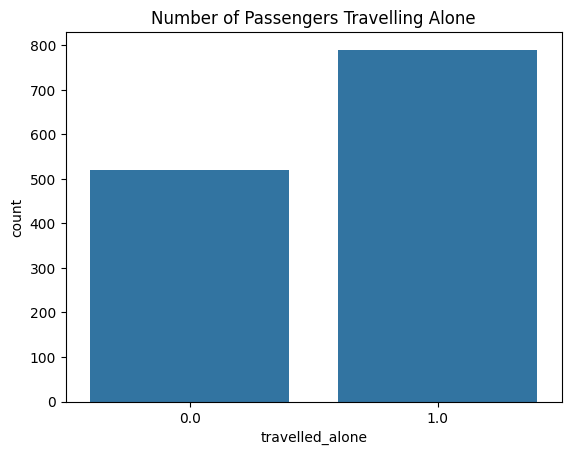

In [13]:
# df.drop(['sibsp','parch'], axis = 1, inplace=True)
sns.countplot(x='travelled_alone',data=df) 
plt.title('Number of Passengers Travelling Alone')
plt.show()

In [14]:
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived,Family,travelled_alone
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1,0,1.0
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1,3,0.0
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,3,0.0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,3,0.0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,3,0.0


In [15]:
df.drop(['name','ticket','home.dest'],axis=1,inplace = True)

In [16]:
df.head()

,pclass,sex,age,sibsp,parch,fare,cabin,embarked,boat,body,survived,Family,travelled_alone
0,1,female,29.0000,0,0,211.3375,B5,S,2,NaN,1,0,1.0
1,1,male,0.9167,1,2,151.5500,C22 C26,S,11,NaN,1,3,0.0
2,1,female,2.0000,1,2,151.5500,C22 C26,S,NaN,NaN,0,3,0.0
3,1,male,30.0000,1,2,151.5500,C22 C26,S,NaN,135.0,0,3,0.0
4,1,female,25.0000,1,2,151.5500,C22 C26,S,NaN,NaN,0,3,0.0


In [17]:
df.drop(['body','cabin','boat'],axis=1,inplace= True)

In [18]:
sex= pd.get_dummies(df['sex'],drop_first=True)
print(sex)

       male
0     False
1      True
2     False
3      True
4     False
...     ...
1304  False
1305  False
1306   True
1307   True
1308   True

[1309 rows x 1 columns]


In [19]:
df.isnull().sum()

pclass               0
sex                  0
age                263
sibsp                0
parch                0
fare                 1
embarked             2
survived             0
Family               0
travelled_alone      0
dtype: int64

In [20]:
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(strategy='mean')


In [21]:
df['age'] = imp_mean.fit_transform(df[['age']])
df['fare'] = imp_mean.fit_transform(df[['fare']])

In [22]:
df.isnull().sum()

pclass             0
sex                0
age                0
sibsp              0
parch              0
fare               0
embarked           2
survived           0
Family             0
travelled_alone    0
dtype: int64

In [23]:
imp_freq= SimpleImputer(strategy='most_frequent')

In [24]:
df['embarked'] = imp_freq.fit_transform(df[['embarked']]).flatten()

In [25]:
df.isnull().sum()

pclass             0
sex                0
age                0
sibsp              0
parch              0
fare               0
embarked           0
survived           0
Family             0
travelled_alone    0
dtype: int64

In [26]:
embark = pd.get_dummies(df['embarked'],drop_first=True)
print(embark)

          Q      S
0     False   True
1     False   True
2     False   True
3     False   True
4     False   True
...     ...    ...
1304  False  False
1305  False  False
1306  False  False
1307  False  False
1308  False   True

[1309 rows x 2 columns]


In [27]:
df.drop(['embarked','sibsp','parch'], axis=1, inplace= True)
df= pd.concat([df,embark], axis = 1)


In [28]:
df.head()

,pclass,sex,age,fare,survived,Family,travelled_alone,Q,S
0,1,female,29.0000,211.3375,1,0,1.0,False,True
1,1,male,0.9167,151.5500,1,3,0.0,False,True
2,1,female,2.0000,151.5500,0,3,0.0,False,True
3,1,male,30.0000,151.5500,0,3,0.0,False,True
4,1,female,25.0000,151.5500,0,3,0.0,False,True


In [29]:
df.head()

,pclass,sex,age,fare,survived,Family,travelled_alone,Q,S
0,1,female,29.0000,211.3375,1,0,1.0,False,True
1,1,male,0.9167,151.5500,1,3,0.0,False,True
2,1,female,2.0000,151.5500,0,3,0.0,False,True
3,1,male,30.0000,151.5500,0,3,0.0,False,True
4,1,female,25.0000,151.5500,0,3,0.0,False,True


In [30]:
for col in df.columns:
    if col == True:
         1
    else :
         0
df.head()

,pclass,sex,age,fare,survived,Family,travelled_alone,Q,S
0,1,female,29.0000,211.3375,1,0,1.0,False,True
1,1,male,0.9167,151.5500,1,3,0.0,False,True
2,1,female,2.0000,151.5500,0,3,0.0,False,True
3,1,male,30.0000,151.5500,0,3,0.0,False,True
4,1,female,25.0000,151.5500,0,3,0.0,False,True


In [31]:
from sklearn.preprocessing import OneHotEncoder
# df[['Q']] = OneHotEncoder().fit_transform(df[['Q']]).toarray()

df[['female','male']] = OneHotEncoder().fit_transform(df[['sex']]).toarray()
df[['female','male']]
df['sex'] = OneHotEncoder().fit_transform(df[['sex']]).toarray()[:,1]
df['sex'] = df[['sex']].astype(int)


In [32]:
df[['Q','S']] = df[['Q','S']].astype(int)
df.head()

,pclass,sex,age,fare,survived,Family,travelled_alone,Q,S,female,male
0,1,0,29.0000,211.3375,1,0,1.0,0,1,1.0,0.0
1,1,1,0.9167,151.5500,1,3,0.0,0,1,0.0,1.0
2,1,0,2.0000,151.5500,0,3,0.0,0,1,1.0,0.0
3,1,1,30.0000,151.5500,0,3,0.0,0,1,0.0,1.0
4,1,0,25.0000,151.5500,0,3,0.0,0,1,1.0,0.0


In [33]:
X = df.drop(['survived','female','male'], axis=1)
X.head()



,pclass,sex,age,fare,Family,travelled_alone,Q,S
0,1,0,29.0000,211.3375,0,1.0,0,1
1,1,1,0.9167,151.5500,3,0.0,0,1
2,1,0,2.0000,151.5500,3,0.0,0,1
3,1,1,30.0000,151.5500,3,0.0,0,1
4,1,0,25.0000,151.5500,3,0.0,0,1


In [34]:
y= df['survived']
y.head()

0    1
1    1
2    0
3    0
4    0
Name: survived, dtype: category
Categories (2, str): ['0', '1']

In [35]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.3, random_state=1) 

In [36]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(916, 8) (916,)
(393, 8) (393,)


In [37]:
from sklearn.linear_model import LogisticRegression
mod = LogisticRegression()
mod.fit(X_train,y_train)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
pred= mod.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test, pred)

0.7964376590330788

In [40]:
confusion_matrix(y_test, pred)

array([[204,  32],
       [ 48, 109]])

K-MEANS
1.Finding the value of k: Hit & Trial/ Elbow Method
2.Measuring Distance : Computing distance between centroids & samples
3.Grouping :Assign data points to the centroids
4.Repositioning : finding optimal position for centroids
5.Convergence: Points where centroids will reach optimal position


In [41]:
#   K_MEANS Implementation
import pandas as pd
import numpy as np
from sklearn import datasets

data = datasets.load_wine()

In [42]:
X = data.data
y= data.target

In [43]:
df = pd.DataFrame(X,columns = data.feature_names)
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [44]:
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [45]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [46]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

In [47]:
from sklearn.cluster import KMeans
wss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init= 'k-means++' , random_state =0)
    kmeans.fit(X)
    wss.append(kmeans.inertia_) 
    print(len(wss))

1
2
3
4
5
6
7
8
9
10


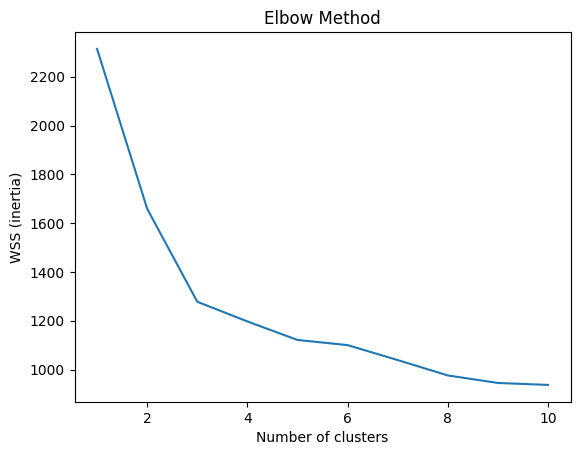

In [48]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),wss)
plt.xlabel('Number of clusters')
plt.ylabel('WSS (inertia)')
plt.title('Elbow Method')
plt.show()

In [49]:
N = 3
kmeans = KMeans(init = 'k-means++',n_clusters = N)
kmeans.fit(X)
labels = kmeans.labels_
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 1 2 1 2 1
 1 2 2 2 1 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 1 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [50]:
from sklearn.metrics import accuracy_score,confusion_matrix, adjusted_rand_score
print(adjusted_rand_score(y,labels))
print(confusion_matrix(y,labels))
# accuracy_score(labels,y)

0.8456161913329393
[[ 0 59  0]
 [ 1  8 62]
 [48  0  0]]
